In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as la
from matplotlib.collections import LineCollection

from tqdm import tqdm

from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala.lattice import cut_boundaries
from koala.graph_utils import make_dual, lloyd_relaxation, remove_trailing_edges
from koala import plotting as kplt
import matplotlib

matplotlib.rcParams.update({'font.size': 11, 'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern']})

In [3]:
def qwz_hamiltonian(lattice, u_vals, h_field = 0):
    if isinstance(u_vals, (int, float, complex)):
        u_vals = np.array([u_vals] * lattice.n_vertices)

    a_site_part = np.diag(u_vals+0j)
    b_site_part = -np.diag(u_vals+0j)

    ab_link_part = np.zeros((lattice.n_vertices, lattice.n_vertices), dtype = complex)
    ba_link_part = np.zeros((lattice.n_vertices, lattice.n_vertices), dtype = complex)

    p1 = lattice.vertices.positions[lattice.edges.indices[:, 0]]
    p2 = lattice.vertices.positions[lattice.edges.indices[:, 1]]   
    average_y = 0.5*(p1[:,1] + p2[:,1])
    change_x = p2[:,0] - p1[:,0]
    phases = -h_field * average_y * change_x * lattice.n_plaquettes

    for edge_index in range(lattice.n_edges):

        field_phase = 1j*phases[edge_index]*2*np.pi
        
        edge = lattice.edges.indices[edge_index]

        vec = lattice.edges.vectors[edge_index]
        angle = np.angle(vec[0] + 1j * vec[1])

        ab_link_part[edge[0], edge[1]] = 0.5j*np.exp(-1j*angle + field_phase)
        ba_link_part[edge[0], edge[1]] = 0.5j*np.exp(1j*angle + field_phase)
        a_site_part[edge[0], edge[1]] = 0.5*np.exp(field_phase)
        b_site_part[edge[0], edge[1]] = -0.5*np.exp(field_phase)

        # add conjugates
        ba_link_part[edge[1], edge[0]] = -0.5j*np.exp(1j*angle - field_phase)
        ab_link_part[edge[1], edge[0]] = -0.5j*np.exp(-1j*angle - field_phase)
        a_site_part[edge[1], edge[0]] = 0.5*np.exp(-field_phase)
        b_site_part[edge[1], edge[0]] = -0.5*np.exp(-field_phase)

    return np.block([
        [a_site_part, ab_link_part],
        [ba_link_part, b_site_part]
    ])

def cmap_triangulation(x_vals, y_vals, z_vals, title=None, xy_labels=None, range=None, show=True, cmap=None):
    if cmap is not None:
        plt.tripcolor(x_vals, y_vals, z_vals, cmap=cmap)
    else:
        plt.tripcolor(x_vals, y_vals, z_vals)
    plt.colorbar()
    if range is not None:
        plt.clim(range[0], range[1])
    if title is not None:
        plt.title(title)
    if xy_labels is not None:
        plt.xlabel(xy_labels[0])
        plt.ylabel(xy_labels[1])

2000 3000 1000


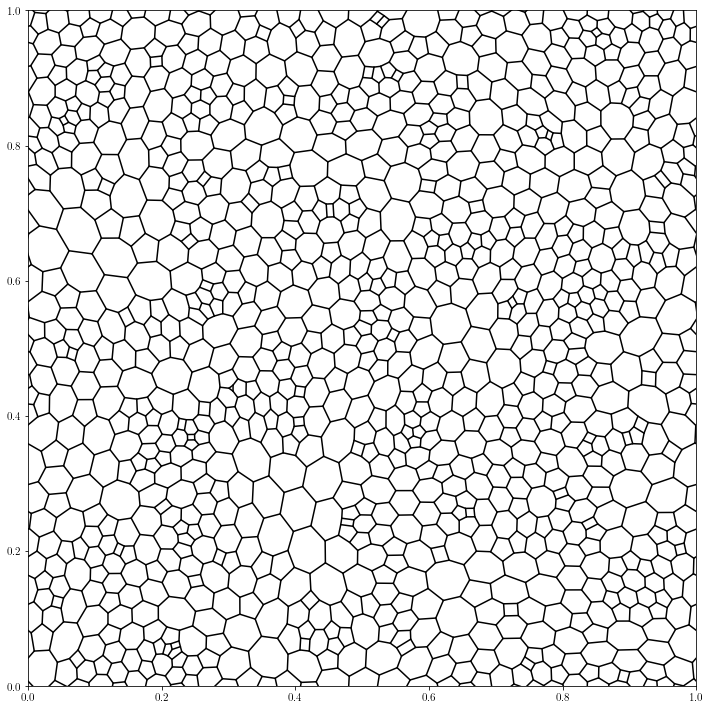

In [5]:
points = uniform(1000)
lattice = lloyd_relaxation(generate_lattice(points))
lattice_strip = remove_trailing_edges(cut_boundaries(lattice, [True, True]))

fig, ax = plt.subplots(figsize=(10,10))
plt.tight_layout()
kplt.plot_edges(lattice, ax = ax)

print(lattice.n_vertices, lattice.n_edges, lattice.n_plaquettes)


In [6]:
h = qwz_hamiltonian(lattice, -0.5)
eigvals, eigvecs = la.eigh(h)


In [64]:
P = eigvecs @ np.diag(eigvals<0) @ eigvecs.T.conj()

In [65]:
angle_from_center = np.angle(lattice.vertices.positions[:,0]-0.5 + 1j*(lattice.vertices.positions[:,1]-0.5))

angle_from_center = np.kron(angle_from_center, np.ones(2))



A = angle_from_center > np.pi/3
B = (angle_from_center < np.pi/3)*(angle_from_center > -np.pi/3)
C = angle_from_center < -np.pi/3

pap = P@ np.diag(A) @P
pbp = P@ np.diag(B) @P

k_marker = (pap @ pbp - pbp @ pap).diagonal().imag

x_vals = lattice.vertices.positions[:,0]
y_vals = lattice.vertices.positions[:,1]
z_vals = k_marker[::2] 


(2000,)


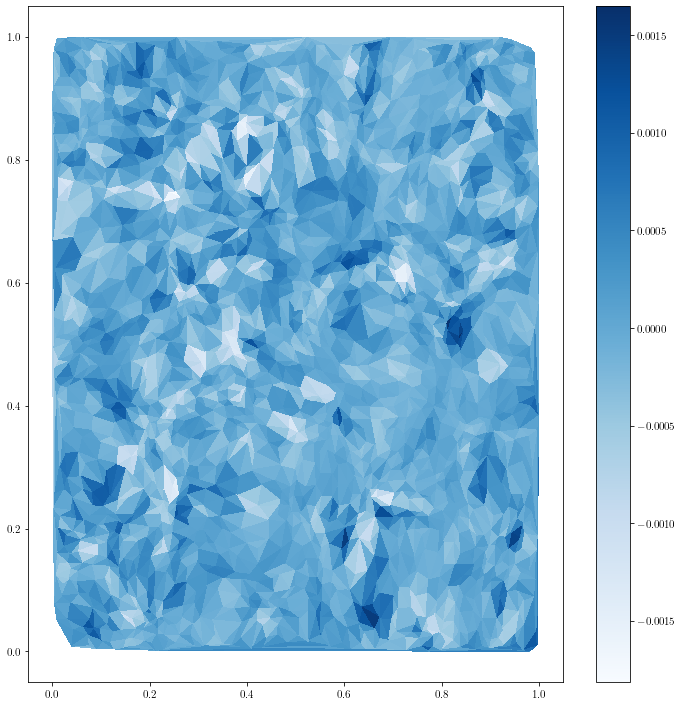

In [66]:
print(z_vals.shape)

fig, ax = plt.subplots(figsize=(10,10))
plt.tight_layout()
plt.tripcolor(x_vals, y_vals, z_vals, cmap='Blues')
plt.colorbar()